# Run Evofr

In [1]:
import numpy as np
import pandas as pd

import evofr as ef

/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [62]:
def prepare_count_data_evofr(counts):
    
    start_date = pd.to_datetime("2025-01-01")
    dates = [start_date + pd.Timedelta(days=day - 1) for day in counts.day]

    counts['day'] = dates

    counts = counts.rename(columns = {"day": "date", "count": "sequences"})

    return counts

In [63]:
counts = pd.read_csv("data/counts_5var_180day.csv")

counts = prepare_count_data_evofr(counts)
counts.head()

,date,variant,sequences
0,2024-12-31,variant_0,959
1,2025-01-01,variant_0,964
2,2025-01-02,variant_0,959
3,2025-01-03,variant_0,947
4,2025-01-04,variant_0,941


In [ ]:
def infer_parameters_forecast_evofr(counts):

    variant_frequencies = ef.VariantFrequencies(counts, pivot="variant_0")

    mlr = ef.MultinomialLogisticRegression(tau=1) # tau: average generation time (1 day)
    inference_method = ef.InferNUTS(num_samples=1000, num_warmup=1000) # num_warmup defines burn in

    posterior = inference_method.fit(mlr, variant_frequencies)

    return posterior

In [23]:
variant_frequencies = ef.VariantFrequencies(counts, pivot="variant_0")

mlr = ef.MultinomialLogisticRegression(tau=4.2) # tau: average generation time
inference_method = ef.InferNUTS(num_samples=1000, num_warmup=1000) # num_warmup defines burn in

In [24]:
posterior = inference_method.fit(mlr, variant_frequencies)

sample: 100%|██████████| 2000/2000 [00:03<00:00, 614.20it/s, 255 steps of size 1.93e-02. acc. prob=0.94]


In [32]:
posterior.samples['beta'][:, 0, :] # parameter estimates: 0 - log_initial_freq, 1 - growth_rate

Array([[-3.7492523, -4.668959 , -4.8894596, -6.240641 ,  0.       ],
       [-3.7525878, -4.6650157, -4.8914247, -6.2417226,  0.       ],
       [-3.7304926, -4.657724 , -4.908399 , -6.224847 ,  0.       ],
       ...,
       [-3.808371 , -4.650501 , -4.8977256, -6.236237 ,  0.       ],
       [-3.7680986, -4.626996 , -4.8750324, -6.1623793,  0.       ],
       [-3.7567308, -4.6922016, -4.926514 , -6.248144 ,  0.       ]],      dtype=float32)

In [33]:
# Use posterior beta to forecast posterior frequenicies. forecast_L defines the number of infection periods to predict in the future

forecast_L = 50
posterior.samples = mlr.forecast_frequencies(posterior.samples, forecast_L)

In [65]:
posterior.samples.keys()

dict_keys(['beta', 'freq', 'ga', 'raw_beta', 'seq_counts', 'freq_forecast', 'delta_bar'])

In [74]:
posterior.samples['ga'].shape

(1000, 4)

In [73]:
posterior.samples['beta'][:, 0, 0]

Array([-3.7492523, -3.7525878, -3.7304926, -3.7616706, -3.743676 ,
       -3.8027978, -3.7968078, -3.7657046, -3.7452812, -3.740536 ,
       -3.7505655, -3.7451563, -3.8156805, -3.799399 , -3.82881  ,
       -3.8283944, -3.7560563, -3.7898529, -3.7797444, -3.77542  ,
       -3.7833078, -3.7466803, -3.7874985, -3.7882984, -3.762165 ,
       -3.7559254, -3.7699482, -3.7937052, -3.7796865, -3.7797542,
       -3.7816784, -3.7653859, -3.7311997, -3.7068331, -3.7888122,
       -3.7545528, -3.7714946, -3.771585 , -3.7649338, -3.7746465,
       -3.7767546, -3.7767286, -3.7771513, -3.7681189, -3.7741349,
       -3.7819333, -3.780682 , -3.7432728, -3.84016  , -3.7379055,
       -3.750462 , -3.7483878, -3.753058 , -3.7521203, -3.7666132,
       -3.7684743, -3.7164881, -3.8308246, -3.7640736, -3.7632277,
       -3.7533567, -3.7710338, -3.765516 , -3.7215476, -3.7169497,
       -3.7233284, -3.7641723, -3.7648146, -3.7805948, -3.7800114,
       -3.7763286, -3.7826512, -3.7682946, -3.731045 , -3.7639

In [37]:
posterior.save_posterior("data/mlr_estimates.pkl")
# Loading new posterior
loaded_posterior = ef.PosteriorHandler(data=variant_frequencies).load_posterior("data/mlr_estimates.pkl")

### Plot results

In [52]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.patches as mpatches

font = {'family' : 'Helvetica',
        'weight' : 'light',
        'size'   : 24}

matplotlib.rc('font', **font)

from evofr.plotting import FrequencyPlot, GrowthAdvantagePlot, PatchLegend, add_dates_sep
from evofr.plotting import plot_site_in_time, plot_variants, plot_time_series_with_variants

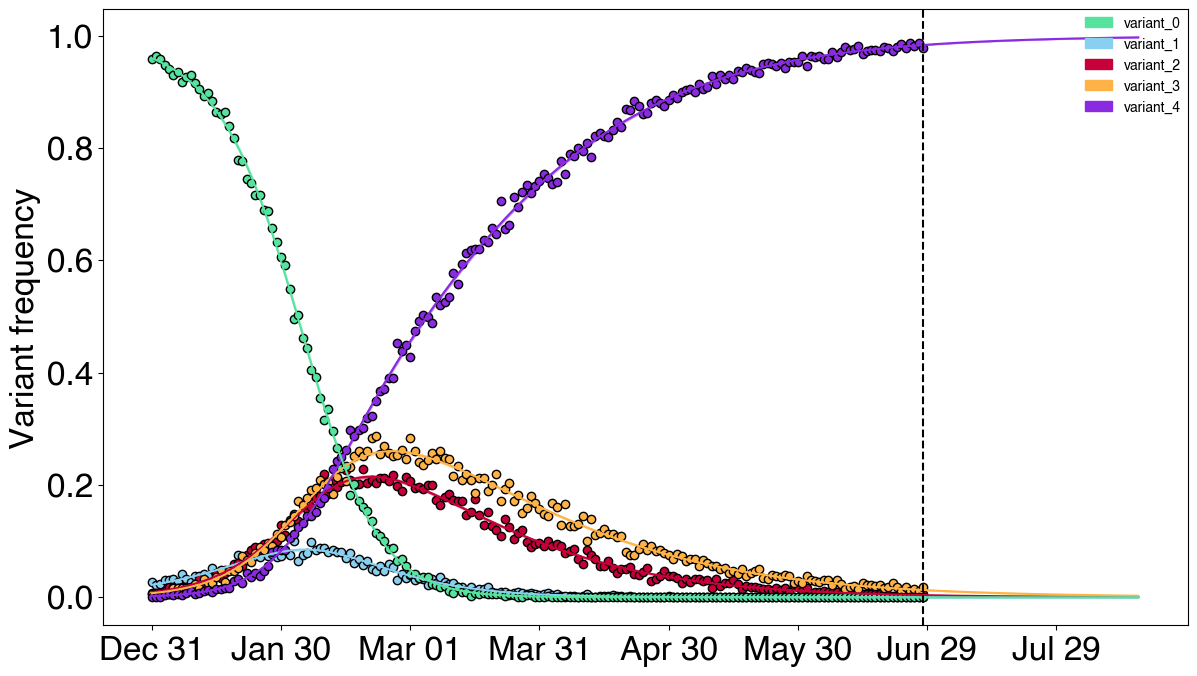

In [54]:
v_colors = ["#56e39f", "#89CFF0", "#C70039", "#FFB347", "#8A2BE2"]
v_names = list(counts.variant.unique())
color_map = {v: c for c, v in zip(v_colors, v_names)}

# Plot predicted frequencies
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(nrows=1, ncols=1)
ax = fig.add_subplot(gs[0,0])

FrequencyPlot(posterior, color_map=color_map).plot(ax, forecast=True)
ax.axvline(x=len(variant_frequencies.dates)-1, color='k', linestyle='--') # Adding forecast cut off
add_dates_sep(ax, ef.data.expand_dates(variant_frequencies.dates, forecast_L), sep=30) # Adding dates

ax.legend(
    handles=[
        mpatches.Patch(color=c, label=v) for v, c in color_map.items()
    ],
    loc='upper right',
    fontsize=10,
    frameon=False,
    ncol=1,  # single column
    borderaxespad=0.1
)

#PatchLegend(color_map, ncol=5).add_legend(ax)


#fig.tight_layout()

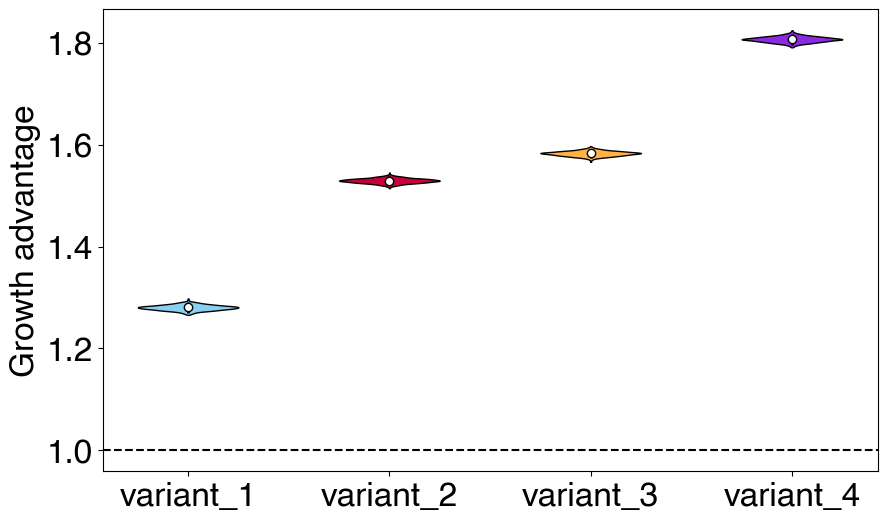

In [56]:
# Plotting growth advantage
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(nrows=1, ncols=1)
ax = fig.add_subplot(gs[0,0])

GrowthAdvantagePlot(posterior, color_map=color_map).plot(ax=ax)

Text(0, 0.5, 'Mean fitness')

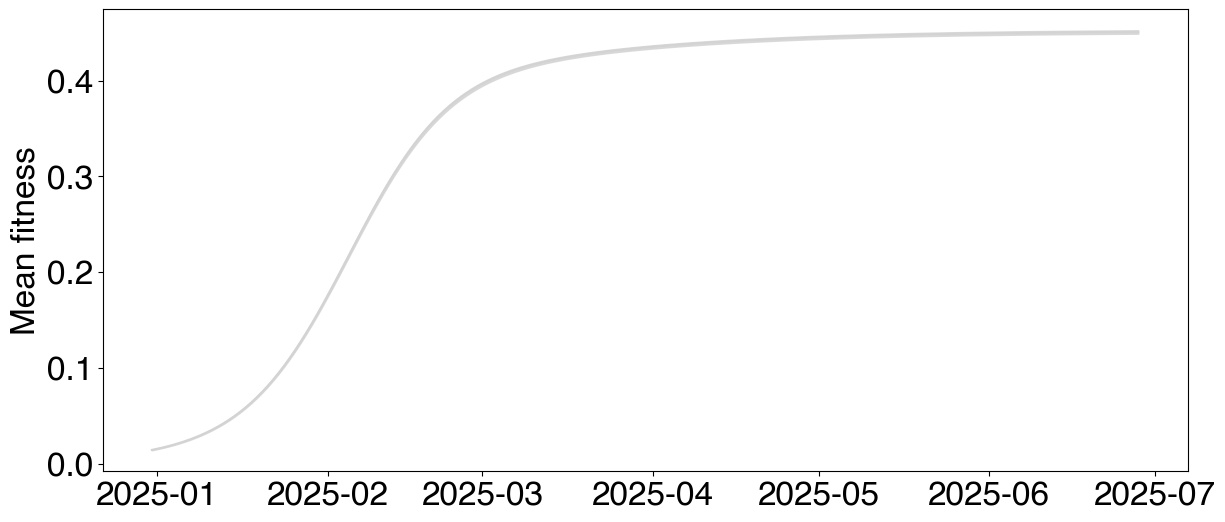

In [57]:
# Computing and plotting mean fitness using `plot_site_in_time` primitive
fig, ax = plt.subplots(figsize=(14,6))
posterior.samples["delta_bar"] = (posterior.samples["freq"][:, :, :-1] * posterior.samples["ga"][:, None, :]).mean(axis=-1)
plot_site_in_time(ax, posterior.samples, "delta_bar", dates = posterior.data.dates, alphas=[0.8], colors="lightgray", quantiles=[0.8])
ax.set_ylabel("Mean fitness")

Text(0, 0.5, 'Growth Advantage')

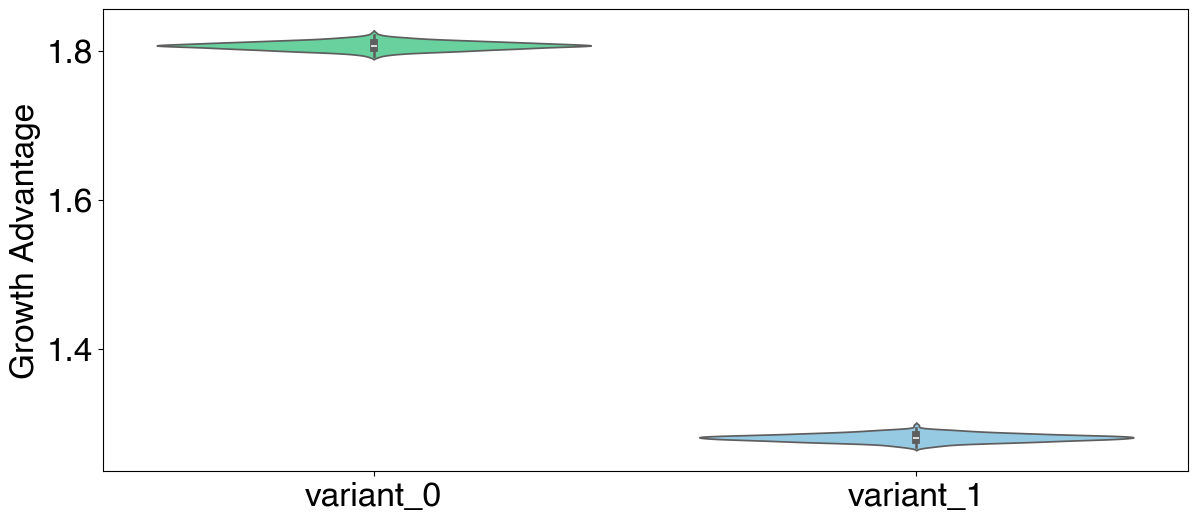

In [59]:
# Plotting growth advantage using `plot_variants` primitive
fig, ax = plt.subplots(figsize=(14,6))
plot_variants(ax, 
              posterior.samples, 
              "ga", 
              color_map=color_map, 
              variants=posterior.data.var_names, 
              variants_to_plot = ["variant_0", "variant_1"])
ax.set_ylabel("Growth Advantage")

Text(0, 0.5, 'Variant Frequency')

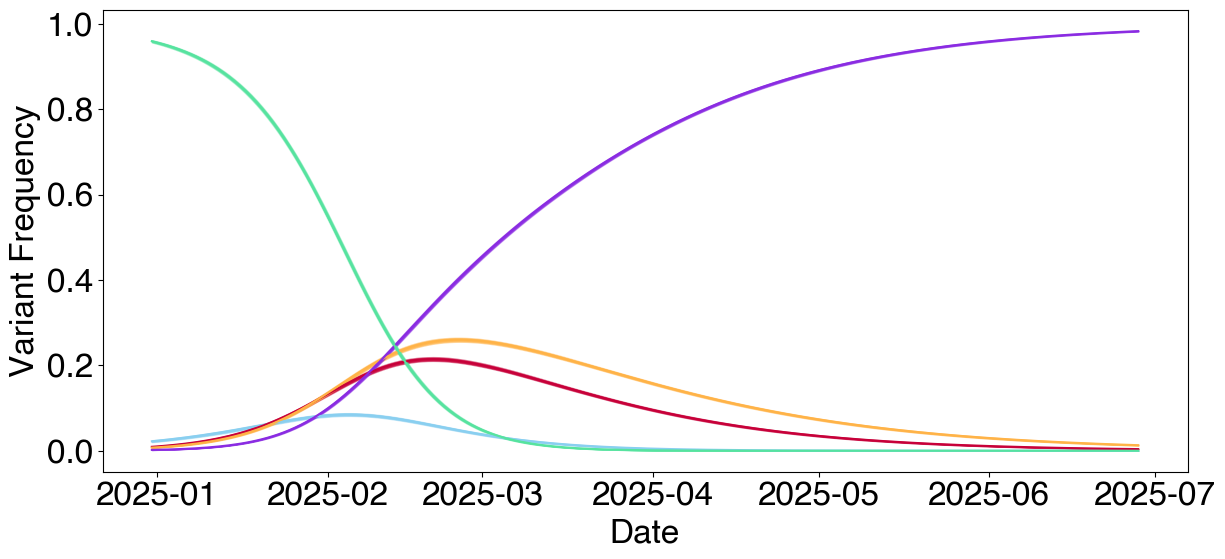

In [60]:
# Plotting variant frequency using `plot_time_series_with_variants` primitive
fig, ax = plt.subplots(figsize=(14,6))
plot_time_series_with_variants(ax, 
                               posterior.samples, "freq", 
                               variants=posterior.data.var_names, 
                               dates = posterior.data.dates,               
                               color_map=color_map, 
                               alphas = [0.5, 0.7],
                               quantiles=[0.99, 0.8]
)
ax.set_ylabel("Variant Frequency")